# **A/B Testing SmartInvest: Perbandingan Model MVEP dan SIM**

## 1\. Pendahuluan

### 1.1 Latar Belakang

SmartInvest merupakan sistem rekomendasi portofolio saham berbasis web yang dikembangkan untuk membantu investor pemula dalam menentukan alokasi investasi yang optimal berdasarkan analisis kuantitatif.

Dalam sistem SmartInvest terdapat beberapa metode optimasi portofolio yang digunakan yaitu:
- Mean Variance Efficient Portfolio (MVEP)
- Single Index Model (SIM)
- Capital Asset Pricing Model (CAPM)

Masing-masing metode memiliki pendekatan yang berbeda dalam membentuk portofolio sehingga dapat menghasilkan tingkat return dan risiko yang berbeda.

Perbandingan difokuskan pada metode **MVEP dan SIM** karena kedua metode menghasilkan rekomendasi bobot portofolio secara langsung sehingga lebih relevan untuk dibandingkan dalam optimasi portofolio. Sementara itu, **CAPM** lebih banyak digunakan untuk mengestimasi expected return berdasarkan risiko sistematis suatu saham.

 Untuk mengevaluasi performa kedua metode tersebut, dilakukan eksperimen menggunakan pendekatan A/B Testing berbasis Python. Pengujian dilakukan menggunakan data historis **saham LQ45** pada **delapan periode semesteran** dari tahun **2022 hingga 2025**. Performa kedua metode dibandingkan berdasarkan **Sharpe Ratio** sebagai indikator **risk-adjusted return**.



### 1.2 Tujuan Eksperimen

Eksperimen ini dilakukan untuk:

* Membandingkan performa portofolio yang dihasilkan oleh metode MVEP dan SIM.
* Menganalisis apakah metode SIM menghasilkan Sharpe Ratio yang lebih tinggi dibandingkan metode MVEP.
* Mengevaluasi metode yang lebih sesuai untuk digunakan sebagai rekomendasi portofolio pada sistem SmartInvest.


### 1.3 Hipotesis


* **Hipotesis Nol (H₀)** : Tidak terdapat perbedaan performa antara metode MVEP dan SIM berdasarkan Sharpe Ratio.

$$
H_0 : \mu_{SIM} = \mu_{MVEP}
$$

* **Hipotesis Alternatif (H₁)** : Terdapat perbedaan performa antara metode MVEP dan SIM berdasarkan Sharpe Ratio.

$$
H_1 : \mu_{SIM} ≠ \mu_{MVEP}
$$

## 2. Setup Eksperimen

Eksperimen dilakukan untuk membandingkan performa dua metode optimasi portofolio yang digunakan dalam sistem SmartInvest, yaitu **Mean Variance Efficient Portfolio (MVEP)** dan **Single Index Model (SIM)**.

Pada eksperimen ini:

* Kelompok A (Kontrol) direpresentasikan oleh metode MVEP.
* Kelompok B (Perlakuan) direpresentasikan oleh metode SIM.
* Metrik utama yang digunakan adalah **Sharpe Ratio** karena mampu mengukur return yang diperoleh terhadap risiko yang ditanggung.
* Pengujian dilakukan menggunakan data **saham LQ45** pada **delapan periode semesteran** dari tahun **2022 hingga 2025**.
* Setiap periode menghasilkan satu nilai Sharpe Ratio untuk masing-masing metode sehingga data bersifat berpasangan (**paired data**).
* Untuk mengetahui apakah terdapat perbedaan performa yang signifikan antara kedua metode, digunakan **uji Paired t-Test** dengan tingkat signifikansi (**α**) sebesar **0.05**.

### 2.1 Import Library

In [ ]:
from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")

### 2.2 Load Dataset

Dataset yang digunakan merupakan hasil simulasi SmartInvest yang berisi performa portofolio metode MVEP dan SIM pada delapan periode pengujian semesteran dari tahun 2022 hingga 2025.

Variabel yang digunakan dalam analisis meliputi:

- Periode
- Model
- Return
- Volatility
- Sharpe Ratio

In [ ]:
df = pd.read_csv("ab_testing_data_semester.csv")

df

,Periode,Model,Return,Volatility,Sharpe
0,2022-H1,MVEP,37.90,14.76,2.3307
1,2022-H1,SIM,144.05,29.73,4.7269
2,2022-H2,MVEP,16.39,9.98,1.2119
3,2022-H2,SIM,75.61,19.63,3.6326
4,2023-H1,MVEP,22.13,9.84,1.6673
5,2023-H1,SIM,57.62,13.27,3.9106
6,2023-H2,MVEP,29.75,10.34,2.3120
7,2023-H2,SIM,262.95,39.81,6.4585
8,2024-H1,MVEP,16.04,16.71,0.6019
9,2024-H1,SIM,83.26,33.16,2.3304


## 3\. Exploratory Analysis

### 3.1 Statistik Deskriptif

Melihat rata-rata performa masing-masing model.

In [ ]:
df.groupby("Model")[["Return", "Volatility", "Sharpe"]].mean()

,Return,Volatility,Sharpe
Model,,,
MVEP,26.34250,13.31125,1.623650
SIM,129.63875,28.48375,4.266913


Berdasarkan rata-rata performa pada seluruh periode pengujian, metode SIM menghasilkan Return dan Sharpe Ratio yang lebih tinggi dibandingkan MVEP. Namun, peningkatan tersebut disertai dengan tingkat Volatility yang juga lebih tinggi.
Secara deskriptif, SIM menunjukkan performa yang lebih baik dibandingkan MVEP. Meskipun demikian, diperlukan pengujian statistik lebih lanjut untuk memastikan apakah perbedaan tersebut signifikan secara statistik.

### 3.2 Visualisasi Sharpe Ratio


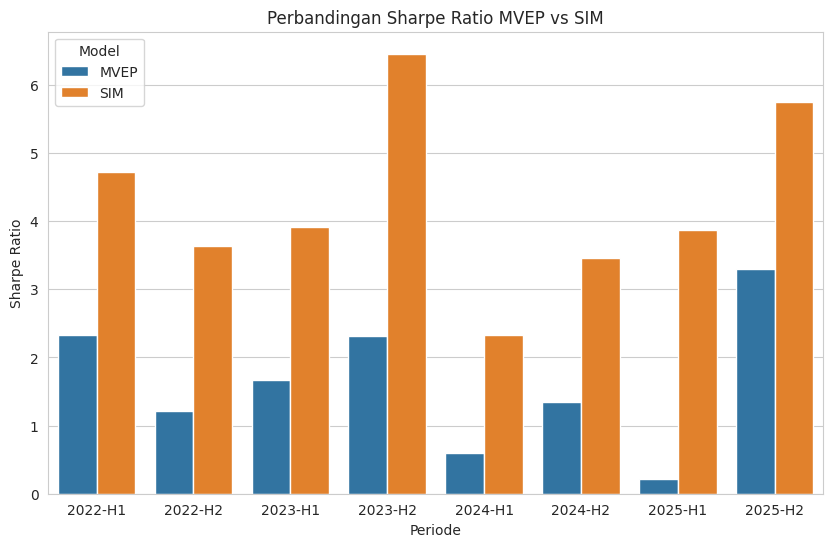

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Periode",
    y="Sharpe",
    hue="Model"
)

plt.title("Perbandingan Sharpe Ratio MVEP vs SIM")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Periode")

plt.show()

Berdasarkan grafik Sharpe Ratio, metode SIM menghasilkan nilai Sharpe Ratio yang lebih tinggi dibandingkan MVEP pada seluruh periode pengujian. Perbedaan terbesar terlihat pada periode 2023-H2 dan 2025-H2, ketika SIM menghasilkan risk-adjusted return yang jauh lebih tinggi. Secara keseluruhan, SIM menunjukkan performa yang lebih baik dibandingkan MVEP berdasarkan metrik Sharpe Ratio.

### 3.3 Visualisasi Annualized Return

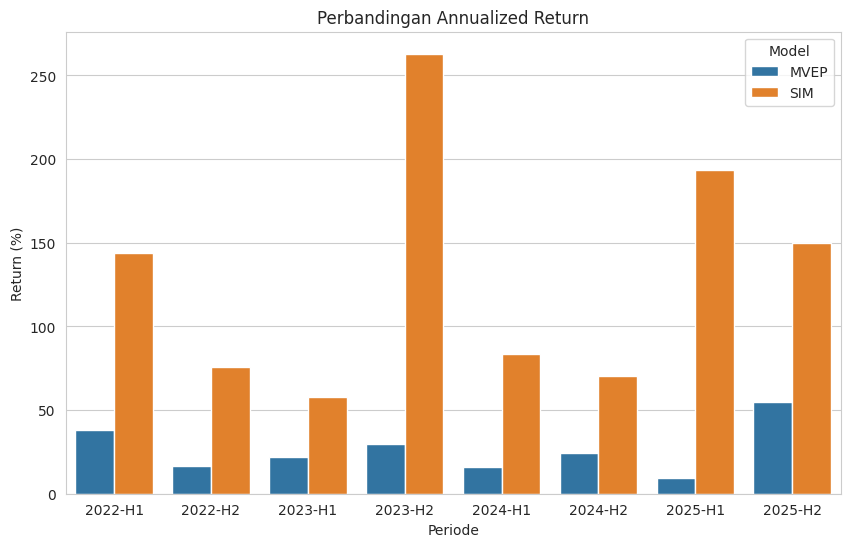

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Periode",
    y="Return",
    hue="Model"
)

plt.title("Perbandingan Annualized Return")
plt.ylabel("Return (%)")

plt.show()

Grafik Annualized Return menunjukkan bahwa metode SIM menghasilkan return yang lebih tinggi dibandingkan MVEP pada seluruh periode pengujian.
Perbedaan return terlihat cukup signifikan pada beberapa periode, terutama 2023-H2 dan 2025-H1. Secara keseluruhan, SIM cenderung memberikan potensi return yang lebih besar dibandingkan MVEP selama periode pengujian.

### 3.4 Visualisasi Annualized Volatility

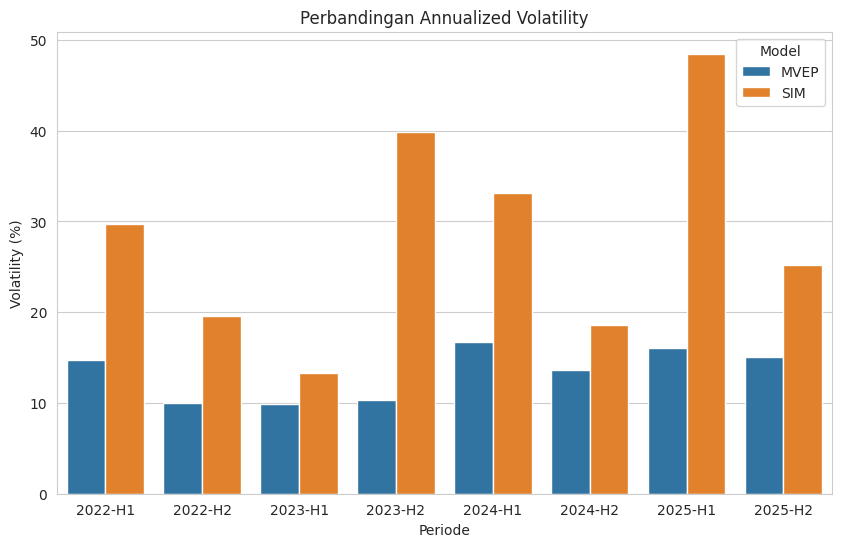

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Periode",
    y="Volatility",
    hue="Model"
)

plt.title("Perbandingan Annualized Volatility")
plt.ylabel("Volatility (%)")

plt.show()

Berdasarkan grafik Annualized Volatility, metode SIM juga menunjukkan tingkat volatilitas yang lebih tinggi dibandingkan MVEP pada seluruh periode pengujian.
Hal ini menunjukkan bahwa return yang lebih tinggi pada metode SIM diperoleh dengan risiko yang lebih besar. Sebaliknya, MVEP cenderung menghasilkan volatilitas yang lebih rendah dan lebih stabil selama periode pengujian.

## 4\. Pengujian Hipotesis

### 4.1 Persiapan Data

Sebelum melakukan pengujian hipotesis, data Sharpe Ratio dari masing-masing metode dipisahkan terlebih dahulu. Data bersifat berpasangan (paired data) karena metode MVEP dan SIM diuji pada periode semester yang sama.


In [ ]:
mvep_sharpe = df[df["Model"] == "MVEP"]["Sharpe"].values
sim_sharpe = df[df["Model"] == "SIM"]["Sharpe"].values

print("MVEP Sharpe:", mvep_sharpe)
print("SIM Sharpe:", sim_sharpe)

MVEP Sharpe: [2.3307 1.2119 1.6673 2.312  0.6019 1.3456 0.2198 3.3   ]
SIM Sharpe: [4.7269 3.6326 3.9106 6.4585 2.3304 3.4573 3.8724 5.7466]


### 4.2 Menghitung Selisih Sharpe Ratio

Pada Paired T-Test, pengujian dilakukan terhadap selisih nilai antar pasangan data.

Oleh karena itu, dihitung selisih Sharpe Ratio antara metode SIM dan MVEP pada setiap periode pengujian.

Rumus yang digunakan:

$$
d_i = Sharpe_{SIM,i} - Sharpe_{MVEP,i}
$$

dengan:

- $d_i$ = selisih Sharpe Ratio pada periode ke-$i$
- $Sharpe_{SIM,i}$ = Sharpe Ratio metode SIM pada periode ke-$i$
- $Sharpe_{MVEP,i}$ = Sharpe Ratio metode MVEP pada periode ke-$i$

In [ ]:
diff = sim_sharpe - mvep_sharpe

print("Selisih Sharpe Ratio:")
print(diff)

Selisih Sharpe Ratio:
[2.3962 2.4207 2.2433 4.1465 1.7285 2.1117 3.6526 2.4466]


### 4.3 Uji Normalitas Selisih

Sebelum melakukan Paired T-Test, dilakukan pengujian normalitas terhadap data selisih Sharpe Ratio menggunakan uji Shapiro-Wilk.

Hipotesis yang digunakan adalah:

* **Hipotesis Nol (H₀)** : Data selisih berdistribusi normal.

* **Hipotesis Alternatif (H₁)** : Data selisih tidak berdistribusi normal.

Apabila nilai p-value lebih besar dari 0.05, maka asumsi normalitas dapat dianggap terpenuhi.

In [ ]:
from scipy.stats import shapiro

shapiro(diff)

ShapiroResult(statistic=np.float64(0.8391247196452458), pvalue=np.float64(0.07377785600798177))

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0.0738.

Karena p-value lebih besar dari 0.05, hipotesis nol gagal ditolak. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa data selisih Sharpe Ratio tidak berdistribusi normal sehingga asumsi normalitas pada Paired T-Test dapat dianggap terpenuhi.

### 4.3 Menghitung Mean dan Standar Deviasi Selisih

Langkah berikutnya adalah menghitung statistik dasar dari nilai selisih Sharpe Ratio yang telah diperoleh.

Statistik yang digunakan meliputi:

- $n$ : jumlah pasangan data
- $\bar{d}$ : rata-rata selisih Sharpe Ratio
- $s_d$ : standar deviasi selisih Sharpe Ratio

Rata-rata selisih dihitung menggunakan rumus:

$$
\bar{d}=\frac{\sum_{i=1}^{n} d_i}{n}
$$

Sedangkan standar deviasi selisih dihitung menggunakan rumus:

$$
s_d=\sqrt{\frac{\sum_{i=1}^{n}(d_i-\bar{d})^2}{n-1}}
$$

Nilai $\bar{d}$ dan $s_d$ akan digunakan dalam perhitungan t-statistic pada Paired T-Test.

In [ ]:
n = len(diff)

mean_diff = np.mean(diff)

std_diff = np.std(
    diff,
    ddof=1
)

print("Jumlah Sampel (n) :", n)
print("Mean Difference   :", round(mean_diff, 4))
print("Std Difference    :", round(std_diff, 4))

Jumlah Sampel (n) : 8
Mean Difference   : 2.6433
Std Difference    : 0.82


### 4.4 Menghitung Degree of Freedom

Degree of Freedom (DoF) digunakan untuk menentukan distribusi t yang sesuai dalam perhitungan p-value.

Karena penelitian ini menggunakan Paired T-Test, derajat kebebasan dihitung berdasarkan jumlah pasangan data dengan rumus:

$$
df = n - 1
$$

dengan:

- $df$ : degree of freedom (derajat kebebasan)
- $n$ : jumlah pasangan data


In [ ]:
dof = n - 1

print("Degree of Freedom :", dof)

Degree of Freedom : 7


### 4.5 Menghitung T-Statistic

Nilai t-statistic digunakan untuk mengukur seberapa besar rata-rata selisih Sharpe Ratio dibandingkan dengan variasi data yang dimiliki.

Pada Paired T-Test, nilai t-statistic dihitung menggunakan rumus:

$$
t = \frac{\bar{d}}{\frac{s_d}{\sqrt{n}}}
$$

dengan:

- $t$ : nilai t-statistic
- $\bar{d}$ : rata-rata selisih Sharpe Ratio
- $s_d$ : standar deviasi selisih Sharpe Ratio
- $n$ : jumlah pasangan data

In [ ]:
t_stat = mean_diff / (
    std_diff / np.sqrt(n)
)

print("T-Statistic :", round(t_stat, 4))

T-Statistic : 9.1172


### 4.6 Menghitung P-Value

P-value digunakan untuk menentukan apakah perbedaan yang diamati cukup signifikan secara statistik untuk menolak hipotesis nol.

Pada penelitian ini digunakan tingkat signifikansi sebesar:

$$
\alpha = 0.05
$$

Karena tujuan pengujian adalah mengetahui apakah terdapat perbedaan performa antara metode MVEP dan SIM, digunakan uji dua sisi (*two-tailed test*). P-value dihitung menggunakan distribusi t berdasarkan nilai t-statistic dan degree of freedom yang telah diperoleh sebelumnya dengan rumus:

$$
p = 2 \times \left(1 - F(|t|)\right)
$$

dengan:

- $p$ : p-value
- $F(|t|)$ : cumulative distribution function (CDF) dari distribusi t
- $t$ : nilai t-statistic
- $df$ : degree of freedom

Keputusan pengujian ditentukan berdasarkan aturan berikut:

- Jika $p-value < \alpha$, maka hipotesis nol ($H_0$) ditolak.
- Jika $p-value \geq \alpha$, maka hipotesis nol ($H_0$) gagal ditolak.

In [ ]:
p_value = 2 * (
    1 - stats.t.cdf(
        abs(t_stat),
        dof
    )
)

print("P-Value :", round(p_value, 4))

P-Value : 0.0


### 4.7 Implementasi dengan scipy

Setelah perhitungan manual dilakukan, pengujian juga dilakukan menggunakan fungsi `ttest_rel()` dari SciPy. Tujuannya untuk memastikan bahwa hasil perhitungan manual konsisten dengan implementasi statistik yang tersedia pada library Python.

In [ ]:
from scipy.stats import ttest_rel

t_stat_scipy, p_value_scipy = ttest_rel(
    sim_sharpe,
    mvep_sharpe
)

print("T-Statistic :", round(t_stat_scipy, 4))
print("P-Value     :", round(p_value_scipy, 4))

T-Statistic : 9.1172
P-Value     : 0.0


Hasil yang diperoleh menggunakan fungsi `ttest_rel()` menghasilkan nilai t-statistic dan p-value yang sama dengan perhitungan manual sebelumnya.
Maka proses perhitungan Paired T-Test yang dilakukan telah sesuai dan menghasilkan hasil yang konsisten.

## 5\. Hasil dan Pembahasan

### 5.1 Interpretasi Hasil


In [ ]:
alpha = 0.05

print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 4))
print("Alpha       :", alpha)

if p_value < alpha:
    print("\nKeputusan  : Tolak H0")
    print("Kesimpulan : Terdapat perbedaan performa yang signifikan antara MVEP dan SIM.")
else:
    print("\nKeputusan  : Gagal menolak H0")
    print("Kesimpulan : Tidak terdapat bukti statistik yang cukup bahwa performa MVEP dan SIM berbeda secara signifikan.")

T-Statistic : 9.1172
P-Value     : 0.0
Alpha       : 0.05

Keputusan  : Tolak H0
Kesimpulan : Terdapat perbedaan performa yang signifikan antara MVEP dan SIM.


Berdasarkan hasil Paired T-Test antara metode MVEP dan SIM, diperoleh:

- T-Statistic = 9.1172
- P-Value = 0.0000

Dengan menggunakan tingkat signifikansi:

$$
\alpha = 0.05
$$

Karena nilai P-Value lebih kecil dari α (0.05), maka keputusan statistik yang diambil adalah menolak hipotesis nol (H₀). Maka dapat disimpulkan bahwa terdapat perbedaan performa yang signifikan secara statistik antara metode MVEP dan SIM berdasarkan Sharpe Ratio.

Berdasarkan nilai rata-rata Sharpe Ratio yang lebih tinggi pada metode SIM, dapat disimpulkan bahwa SIM menghasilkan performa portofolio yang lebih baik dibandingkan MVEP selama periode pengujian yang digunakan.

### 5.2 Implikasi Bisnis

Hasil pengujian menunjukkan bahwa metode SIM menghasilkan performa yang secara signifikan lebih baik dibandingkan MVEP berdasarkan Sharpe Ratio.

Dari sisi bisnis, temuan ini menunjukkan bahwa metode SIM memiliki potensi yang lebih besar untuk digunakan sebagai dasar rekomendasi portofolio pada sistem SmartInvest karena mampu menghasilkan risk-adjusted return yang lebih tinggi selama periode pengujian.

Meskipun demikian, metode SIM juga menghasilkan tingkat volatilitas yang lebih tinggi dibandingkan MVEP. Oleh karena itu, penerapan metode rekomendasi tetap perlu mempertimbangkan profil risiko pengguna. Investor yang lebih konservatif mungkin masih dapat mempertimbangkan portofolio yang dihasilkan oleh MVEP, sedangkan investor yang bersedia menerima risiko lebih tinggi dapat memanfaatkan rekomendasi berbasis SIM untuk memperoleh potensi return yang lebih besar.

## 6. Kesimpulan

Berdasarkan hasil A/B Testing menggunakan Paired T-Test, terdapat perbedaan performa yang signifikan antara metode MVEP dan SIM berdasarkan Sharpe Ratio pada delapan periode pengujian semesteran tahun 2022–2025.

Dengan nilai P-Value yang lebih kecil dari tingkat signifikansi 0.05, hipotesis nol (H₀) ditolak. Hasil ini menunjukkan bahwa perbedaan performa yang diamati tidak terjadi secara kebetulan secara statistik.

Berdasarkan rata-rata Sharpe Ratio yang diperoleh selama periode pengujian, metode SIM menunjukkan performa yang lebih baik dibandingkan MVEP. Oleh karena itu, SIM memiliki potensi yang lebih besar untuk digunakan sebagai metode rekomendasi portofolio dalam sistem SmartInvest, dengan tetap mempertimbangkan tingkat risiko dan karakteristik pengguna.